# Bayes and Naive Bayes: guided coding practice



In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
np.set_printoptions(precision=5, suppress=True)
print("Ready! Class order in manual examples: Insulator, Metal.")

Ready! Class order in manual examples: Insulator, Metal.


## 1. Count first, calculate second

Rows: perovskite / not perovskite. Columns: oxide / not oxide. Conditioning changes the denominator

In [57]:
counts = np.array([[3, 2], [4, 4]])
total = counts.sum()
p_oxide = counts[:, 0].sum() / total
p_perovskite = counts[0, :].sum() / total
p_joint = counts[0, 0] / total
p_perovskite_given_oxide = counts[0, 0] / counts[:, 0].sum()
p_oxide_given_perovskite = counts[0, 0] / counts[0, :].sum()
print("P(O), P(P), P(P and O):", p_oxide, p_perovskite, p_joint)
print("P(P|O), P(O|P):", p_perovskite_given_oxide, p_oxide_given_perovskite)
assert np.isclose(p_perovskite_given_oxide, 3/7)

P(O), P(P), P(P and O): 0.5384615384615384 0.38461538461538464 0.23076923076923078
P(P|O), P(O|P): 0.42857142857142855 0.6


**Try it yourself:** Calculate P(not oxide | perovskite). Answer: 0.4. Why are P(P|O) and P(O|P) different?

**Solution 1:** P(P|O) and P(O|P) share the same numerator, the joint count P(P and O) = 3/13, but have different denominators. P(P|O) divides by the oxide total (7); P(O|P) divides by the perovskite total (5).  Bayes' rule links them: P(P|O) = P(O|P)P(P)/P(O).

In [58]:
p_not_oxide_given_perovskite = counts[0, 1] / counts[0, :].sum()
print("P(not O | P):", p_not_oxide_given_perovskite)
assert np.isclose(p_not_oxide_given_perovskite, 0.4)
assert np.isclose(p_not_oxide_given_perovskite + p_oxide_given_perovskite, 1)  # complements within the same condition
# Bayes check: P(P|O) = P(O|P) P(P) / P(O)
assert np.isclose(p_oxide_given_perovskite * p_perovskite / p_oxide, p_perovskite_given_oxide)
print("P(P|O) =", p_perovskite_given_oxide, "!= P(O|P) =", p_oxide_given_perovskite)

P(not O | P): 0.4
P(P|O) = 0.42857142857142855 != P(O|P) = 0.6


## 2. Bayes for screening stable materials

 $P(S|+) = P(+|S)P(S)/[P(+|S)P(S)+P(+|\neg S)P(\neg S)]$. A false-positive rate is conditional on an unstable material.

After one flag: 0.2400; after two: 0.6545


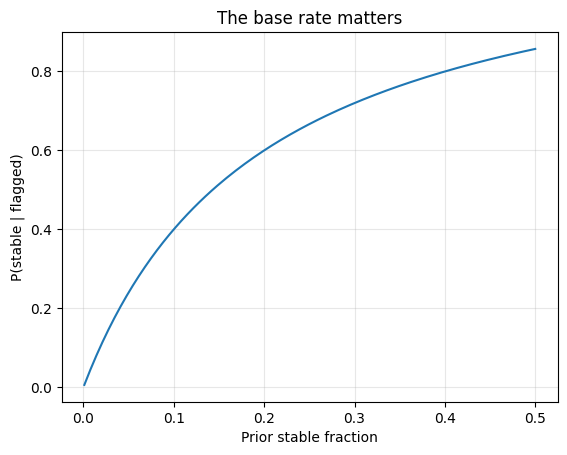

In [59]:
def posterior_positive(prior, sensitivity, false_positive_rate):
    true_positive = sensitivity * prior
    false_positive = false_positive_rate * (1 - prior)
    return true_positive / (true_positive + false_positive)

first = posterior_positive(0.05, 0.90, 0.15)
second = posterior_positive(first, 0.90, 0.15)
print(f"After one flag: {first:.4f}; after two: {second:.4f}")
assert np.isclose(first, 0.24)
priors = np.linspace(0.001, 0.5, 150)
plt.plot(priors, posterior_positive(priors, 0.9, 0.15))
plt.xlabel('Prior stable fraction'); plt.ylabel('P(stable | flagged)')
plt.title('The base rate matters'); plt.grid(alpha=0.3); plt.show()

**Try it yourself:** Change the prior to 0.01. Answer: approximately 0.05714. The second update assumes tests are independent **conditional on stability**, with the same class-conditional rates; rerunning the same deterministic filter is not new evidence.

**Solution 2:** With a 1% prior, the numerator is 0.90 x 0.01 = 0.009 and the denominator is 0.009 + 0.15 x 0.99 = 0.1575, giving about 0.05714. A low base rate means most flagged materials are still false positives. The second update treats the two tests as independent *given stability*; re-running the same deterministic filter gives perfectly correlated results, so it adds no new evidence and the posterior should not be updated again.

In [60]:
p_new = posterior_positive(0.01, 0.90, 0.15)
print(f"Prior 0.01 -> posterior after one flag: {p_new:.5f}")
assert np.isclose(p_new, 0.05714, atol=1e-5)

Prior 0.01 -> posterior after one flag: 0.05714


## 3. Update a distribution, not just a number

 with a Beta(a,b) prior, k successes in n trials give Beta(a+k,b+n−k). Its mean is a/(a+b).

Posterior parameters: 8 22
Prior mean: 0.2 Posterior mean: 0.26666666666666666


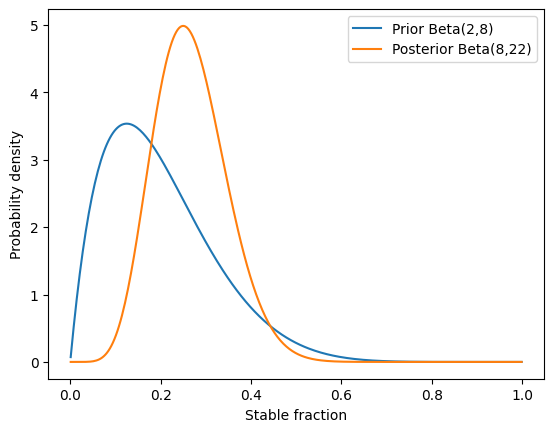

In [61]:
a, b = 2, 8
k, n = 6, 20
a_post, b_post = a + k, b + n - k
print('Posterior parameters:', a_post, b_post)
print('Prior mean:', a/(a+b), 'Posterior mean:', a_post/(a_post+b_post))
grid = np.linspace(0.001, 0.999, 300)
plt.plot(grid, beta.pdf(grid, a, b), label='Prior Beta(2,8)')
plt.plot(grid, beta.pdf(grid, a_post, b_post), label='Posterior Beta(8,22)')
plt.xlabel('Stable fraction'); plt.ylabel('Probability density')
plt.legend(); plt.show()

**Try it yourself:** Observe 1 more success in 10 new trials. Answer: Beta(9,31), mean 0.225. Do not add the old observations twice.

**Solution 3:** The posterior Beta(8,22) already contains the first 20 trials, so it becomes the new prior. Adding k=1, n=10 gives Beta(8+1, 22+9) = Beta(9,31). Re-adding the old data (starting again from Beta(2,8) with 7 successes in 30) would give the same answer only if done once; adding the old counts on top of Beta(8,22) would count them twice.

Updated posterior: 9 31 mean: 0.225


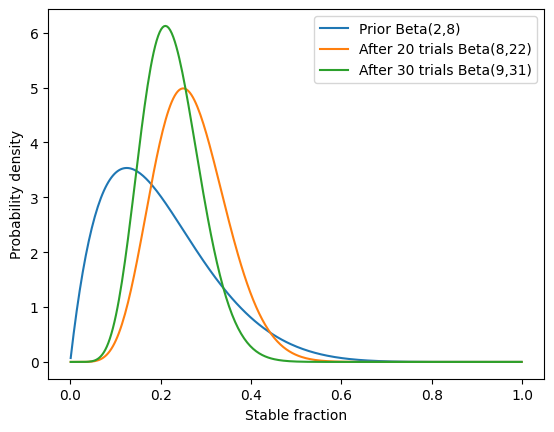

In [62]:
a2, b2 = a_post, b_post          # yesterday's posterior is today's prior
k2, n2 = 1, 10
a3, b3 = a2 + k2, b2 + n2 - k2
print("Updated posterior:", a3, b3, "mean:", a3/(a3+b3))
assert (a3, b3) == (9, 31) and np.isclose(a3/(a3+b3), 0.225)
# same result by batch updating all 30 trials from the original prior
assert (a + 7, b + 30 - 7) == (a3, b3)
plt.plot(grid, beta.pdf(grid, a, b), label='Prior Beta(2,8)')
plt.plot(grid, beta.pdf(grid, a_post, b_post), label='After 20 trials Beta(8,22)')
plt.plot(grid, beta.pdf(grid, a3, b3), label='After 30 trials Beta(9,31)')
plt.xlabel('Stable fraction'); plt.ylabel('Probability density'); plt.legend(); plt.show()

## 4. Discrete Naive Bayes scores

 multiply the prior by the likelihood of each **observed feature value**, then normalize across classes. The naive assumption is conditional independence given the class.

In [63]:
priors = np.array([2/3, 1/3])
# Columns: oxide, coordination number 6, density below 5 g/cm^3
likelihoods = np.array([[0.8, 0.5, 0.6], [0.3, 0.3, 0.4]])
scores = priors * np.prod(likelihoods, axis=1)
probabilities = scores / scores.sum()
print('Scores:', scores)
print('Probabilities [I, M]:', probabilities)
print('Prediction:', ['Insulator', 'Metal'][np.argmax(probabilities)])
assert np.isclose(probabilities[0], 40/43)

Scores: [0.16  0.012]
Probabilities [I, M]: [0.93023 0.06977]
Prediction: Insulator


**Try it yourself:** Replace oxide with not oxide by complementing only the first column. Answer: P(I|features) ≈ 0.58824.

**Solution 4:** Only the oxide likelihood changes. The not oxide likelihoods are the complements 1 - 0.8 = 0.2 (Insulator) and 1 - 0.3 = 0.7 (Metal). Scores: Insulator = 2/3 x 0.2 x 0.5 x 0.6 = 0.04, Metal = 1/3 x 0.7 x 0.3 x 0.4 = 0.028, so P(I|features) = 0.04/0.068 = 0.58824. The prediction is still Insulator, but far less confidently (0.93 before).

In [64]:
lik2 = likelihoods.copy()
lik2[:, 0] = 1 - lik2[:, 0]                  # complement only the first column
sc2 = priors * np.prod(lik2, axis=1)
prob2 = sc2 / sc2.sum()
print("Scores:", sc2, "Probabilities [I, M]:", prob2)
assert np.isclose(prob2[0], 0.58824, atol=1e-5)

Scores: [0.04  0.028] Probabilities [I, M]: [0.58824 0.41176]


## 5. Avoid a zero likelihood
 Laplace smoothing adds one count to **every possible category**. For a binary feature the denominator becomes N+2.

In [65]:
def laplace(count, class_total, n_categories=2):
    return (count + 1) / (class_total + n_categories)

p_perovskite = np.array([laplace(10, 60), laplace(0, 30)])
scores = priors * p_perovskite * np.array([0.8, 0.3]) * np.array([0.6, 0.4])
print('Smoothed perovskite likelihoods [I, M]:', p_perovskite)
print('Posterior [I, M]:', scores / scores.sum())

Smoothed perovskite likelihoods [I, M]: [0.17742 0.03125]
Posterior [I, M]: [0.97846 0.02154]


**Try it yourself:** Use n_categories=3 for a different three-valued feature. Why must the denominator change? Here we smooth only the new perovskite likelihood; other likelihoods are supplied estimates.

**Solution 5:** Laplace smoothing adds 1 pseudo-count to *each* of the K possible categories, so K pseudo-counts are added in total to the class total. The denominator must therefore be N + K for the smoothed probabilities of all K categories to sum to 1. With a binary feature K=2 (N+2); with a three-valued feature K=3 (N+3). Using N+2 for three categories would make the probabilities sum to more than 1.

In [66]:
# three-valued feature, e.g. counts [10, 0, 5] in a class of 15
counts3 = np.array([10, 0, 5]); N3 = counts3.sum()
p3 = np.array([laplace(c, N3, n_categories=3) for c in counts3])
print("Smoothed 3-category probabilities:", p3, "sum =", p3.sum())
assert np.isclose(p3.sum(), 1)
wrong = np.array([laplace(c, N3, n_categories=2) for c in counts3])
print("With wrong denominator N+2, sum =", wrong.sum())   # > 1, invalid
# the perovskite example with n_categories=3 (smoothing only that new likelihood)
p_perov3 = np.array([laplace(10, 60, 3), laplace(0, 30, 3)])
sc5 = priors * p_perov3 * np.array([0.8, 0.3]) * np.array([0.6, 0.4])
print("Likelihoods [I, M]:", p_perov3, "Posterior [I, M]:", sc5/sc5.sum())

Smoothed 3-category probabilities: [0.61111 0.05556 0.33333] sum = 1.0
With wrong denominator N+2, sum = 1.0588235294117647
Likelihoods [I, M]: [0.1746 0.0303] Posterior [I, M]: [0.97877 0.02123]


## 6. Gaussian densities and classification

continuous descriptors use Gaussian densities. Each row below is a class, each column a feature: density (g/cm³), atomic size (Å), electronegativity difference.

In [67]:
means = np.array([[4.0, 1.3, 2.1], [4.0, 0.6, 0.4]])
stds = np.array([[2.0, 0.2, 0.4], [2.0, 0.2, 0.3]])
x = np.array([3.0, 0.9, 1.5])
def gaussian_pdf(x, mu, sigma):
    return np.exp(-0.5*((x-mu)/sigma)**2) / (sigma*np.sqrt(2*np.pi))
z = (x - means) / stds
heights = gaussian_pdf(x, means, stds)
scores = priors * np.prod(heights, axis=1)
print('z-scores:\n', z)
print('Densities:\n', heights)
print('Posterior [I, M]:', scores/scores.sum())
assert np.isclose((scores/scores.sum())[0], 0.994, atol=0.001)

z-scores:
 [[-0.5     -2.      -1.5    ]
 [-0.5      1.5      3.66667]]
Densities:
 [[0.17603 0.26995 0.32379]
 [0.17603 0.64759 0.0016 ]]
Posterior [I, M]: [0.9941 0.0059]


**Try it yourself:** Use x=[5.0,0.7,0.6]. P(I|x) is approximately 2.08e-5. Explain why a density greater than one is valid. Identical density-feature distributions contribute no class discrimination.

**Solution 6:**
- **Density > 1 is valid:** a Gaussian pdf is a density, not a probability. Probabilities come from integrating over an interval, and only the *area* must be 1. A narrow distribution (small sigma) has a tall peak: at the mean the height is 1/(sigma*sqrt(2*pi)), which exceeds 1 whenever sigma < 0.399. E.g. sigma = 0.2 gives about 1.99.
- **Density feature gives no discrimination:** both classes have mean 4.0 and std 2.0, so that feature's density is the same factor for both classes. It cancels when normalizing and does not change the posterior.

In [68]:
x2 = np.array([5.0, 0.7, 0.6])
h2 = gaussian_pdf(x2, means, stds)
sc6 = priors * np.prod(h2, axis=1)
post6 = sc6 / sc6.sum()
print("Densities:\n", h2)
print("Posterior [I, M]:", post6)
assert np.isclose(post6[0], 2.08e-5, rtol=0.02)
print("Max pdf height for sigma=0.2:", gaussian_pdf(0, 0, 0.2), "(> 1, still valid)")
print("Density-feature factors identical across classes:", np.allclose(h2[0, 0], h2[1, 0]))

Densities:
 [[0.17603 0.02216 0.00088]
 [0.17603 1.76033 1.06483]]
Posterior [I, M]: [0.00002 0.99998]
Max pdf height for sigma=0.2: 1.9947114020071635 (> 1, still valid)
Density-feature factors identical across classes: True


## 7. Stable calculations with logarithms
 log score = log prior + sum of log densities. Subtracting the largest log score before exponentiation prevents numerical underflow during normalization.

In [69]:
def normalize_log_scores(log_scores):
    shifted = log_scores - np.max(log_scores)
    weights = np.exp(shifted)
    return weights / weights.sum()

def gaussian_log_scores(x, means, stds, priors):
    log_densities = -np.log(stds*np.sqrt(2*np.pi)) - 0.5*((x-means)/stds)**2
    return np.log(priors) + np.sum(log_densities, axis=1)

print('Direct exponentials:', np.exp(np.array([-1000.0, -1002.0])))
print('Stable probabilities:', normalize_log_scores(np.array([-1000.0, -1002.0])))
log_scores = gaussian_log_scores(x, means, stds, priors)
assert np.allclose(normalize_log_scores(log_scores), scores/scores.sum())

Direct exponentials: [0. 0.]
Stable probabilities: [0.8808 0.1192]


**Try it yourself:** Add 5000 to both log scores. The probabilities stay the same because only relative scores matter.

**Solution 7:** Subtracting the max log score shifts all scores by the same constant, which cancels in the ratio exp(s_i + c) / sum exp(s_j + c). Adding 5000 therefore changes nothing after the max-shift, whereas calling np.exp directly on values near -1000 or +5000 underflows to 0 or overflows to inf.

In [70]:
base = np.array([-1000.0, -1002.0])
shifted = base + 5000
print("Original:", normalize_log_scores(base))
print("+5000   :", normalize_log_scores(shifted))
assert np.allclose(normalize_log_scores(base), normalize_log_scores(shifted))
with np.errstate(over='ignore'):
    print("Naive exp of +5000 scores:", np.exp(np.array([4000.0, 3998.0])))

Original: [0.8808 0.1192]
+5000   : [0.8808 0.1192]
Naive exp of +5000 scores: [inf inf]


## 8. Train GaussianNB on a small dataset

This extension connects the PDF to a machine-learning workflow. Split before fitting. The generated classes are deliberately simple; a high score here does not demonstrate real chemical predictive power.

In [71]:
# Synthetic descriptors only: no experimental or DFT data.
rng = np.random.default_rng(42)
X_I = rng.normal([4.0, 1.3, 2.1], [0.6, 0.25, 0.4], size=(60, 3))
X_M = rng.normal([4.0, 0.6, 0.4], [0.6, 0.25, 0.3], size=(30, 3))
X = np.vstack([X_I, X_M])
y = np.array(['Insulator']*60 + ['Metal']*30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=7, stratify=y)
print('Train/test shapes:', X_train.shape, X_test.shape)
model = GaussianNB()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('Class order:', model.classes_)
print('Training class means:\n', model.theta_)
print('Test accuracy:', accuracy_score(y_test, pred))
print('Confusion matrix (rows=true, columns=predicted):')
print(confusion_matrix(y_test, pred, labels=model.classes_))
print('New-material probabilities:', model.predict_proba([[3, 0.9, 1.5]]))
assert np.allclose(model.predict_proba(X_test).sum(axis=1), 1)

Train/test shapes: (60, 3) (30, 3)
Class order: ['Insulator' 'Metal']
Training class means:
 [[3.95804 1.26188 2.07217]
 [3.90805 0.63337 0.38732]]
Test accuracy: 1.0
Confusion matrix (rows=true, columns=predicted):
[[20  0]
 [ 0 10]]
New-material probabilities: [[0.91696 0.08304]]


**Try it yourself:** Calculate each class mean yourself with X_train[y_train == label].mean(axis=0). For the maximum-likelihood variance use var(axis=0, ddof=0); sklearn also adds a small variance-stabilizing term. Never estimate model parameters from test labels.

**Solution 8:** GaussianNB fits, per class, the mean and variance of each feature using only the training set, plus the class priors from training frequencies. Using test labels to estimate parameters would leak information and inflate the score. 

In [72]:
for i, label in enumerate(model.classes_):
    Xc = X_train[y_train == label]
    mu = Xc.mean(axis=0)
    var_ml = Xc.var(axis=0, ddof=0)
    print(label, "mean:", mu, "ML var:", var_ml)
    assert np.allclose(mu, model.theta_[i])
    # sklearn variance = ML variance + epsilon_
    assert np.allclose(var_ml + model.epsilon_, model.var_[i])
print("epsilon_ (variance smoothing):", model.epsilon_)
prior_manual = np.array([(y_train == c).mean() for c in model.classes_])
assert np.allclose(prior_manual, model.class_prior_)
# manual posterior for the new material using the fitted parameters
xn = np.array([3, 0.9, 1.5])
ls = np.log(model.class_prior_) + np.sum(-0.5*np.log(2*np.pi*model.var_) - 0.5*(xn-model.theta_)**2/model.var_, axis=1)
print("Manual posterior:", normalize_log_scores(ls), "sklearn:", model.predict_proba([xn])[0])
assert np.allclose(normalize_log_scores(ls), model.predict_proba([xn])[0])

Insulator mean: [3.95804 1.26188 2.07217] ML var: [0.22127 0.03954 0.10699]
Metal mean: [3.90805 0.63337 0.38732] ML var: [0.3546  0.07222 0.13256]
epsilon_ (variance smoothing): 7.463374910445794e-10
Manual posterior: [0.91696 0.08304] sklearn: [0.91696 0.08304]
